# CIV4 Who's Where - Dataset Inspection

## Goal of this notebook
This notebook is the first step for a CNN pipeline based on a pretrained PyTorch model to identify and classify ground-dwelling animal groups from drone-view imagery.

## Available data
- RGB images: `data/rgb_images/{train,val,test}`
- Matched labels: `data/labels_matched_rgb/{train,val,test}`
- Label format: one `.txt` file per image frame using YOLO format
  - `class_id x_center y_center width height`
  - all coordinates are normalized to `[0, 1]` relative to image size

## Plan

- We don't care about order
- So find groups/clusters of animals
- lable the group with animal type
- cut out animal type!
- save in folder of animal type
- anotate cutouts
- 

## Looking at an image

**What this section does**

1. Load one sample image-label pair (`55_4650`).
2. Convert normalized YOLO coordinates into pixel coordinates.
3. Draw and display bounding boxes directly on the image.

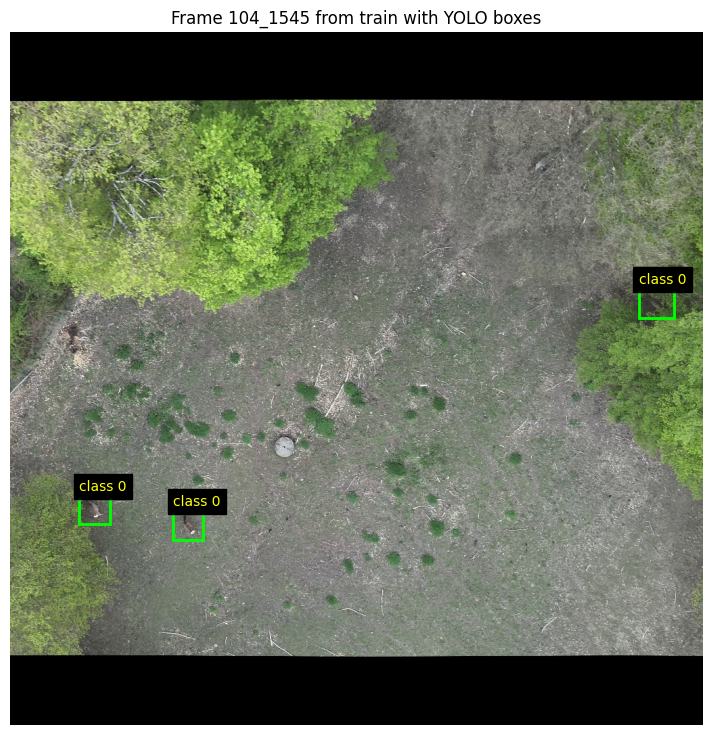

Split: train
Image size: 1024 x 1024
Label file: 104_1545.txt
Number of boxes: 3


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


def yolo_to_xyxy(x_center, y_center, width, height, image_width, image_height):
    x_center_px = x_center * image_width
    y_center_px = y_center * image_height
    width_px = width * image_width
    height_px = height * image_height

    x_min = x_center_px - (width_px / 2)
    y_min = y_center_px - (height_px / 2)
    return x_min, y_min, width_px, height_px


def resolve_frame_paths(frame_id, project_root):
    """Find the split (train/val/test) where both image and label exist for a frame."""
    for split in ("train", "val", "test"):
        image_path = project_root / "data" / "rgb_images" / split / f"{frame_id}.jpg"
        label_path = project_root / "data" / "labels_matched_rgb" / split / f"{frame_id}.txt"
        if image_path.exists() and label_path.exists():
            return split, image_path, label_path

    raise FileNotFoundError(
        f"Could not find matching JPG and TXT for frame '{frame_id}' in train/val/test."
    )


def show_frame_with_boxes(frame_id, project_root=None):
    """Load a frame by id, auto-detect split, and visualize YOLO boxes."""
    if project_root is None:
        cwd = Path.cwd().resolve()
        project_root = cwd.parent if cwd.name == "notebooks" else cwd

    split, image_path, label_path = resolve_frame_paths(frame_id, project_root)

    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    boxes = []
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            class_id, x_c, y_c, w, h = line.split()
            boxes.append((int(class_id), float(x_c), float(y_c), float(w), float(h)))

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(image)

    for class_id, x_c, y_c, w, h in boxes:
        x_min, y_min, box_w, box_h = yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h)
        rect = patches.Rectangle((x_min, y_min), box_w, box_h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x_min, max(y_min - 6, 2), f"class {class_id}", color="yellow", fontsize=10, backgroundcolor="black")

    ax.set_title(f"Frame {frame_id} from {split} with YOLO boxes")
    ax.axis("off")
    plt.show()

    print(f"Split: {split}")
    print(f"Image size: {img_w} x {img_h}")
    print(f"Label file: {label_path.name}")
    print(f"Number of boxes: {len(boxes)}")

    return {
        "split": split,
        "image_path": image_path,
        "label_path": label_path,
        "image_size": (img_w, img_h),
        "num_boxes": len(boxes),
        "boxes": boxes,
    }


# Demo: show the same frame currently used in this notebook.
frame_info = show_frame_with_boxes("104_1545")

## Cutting out the clustered group

**What this section does**

1. Load the image and the bounding box
2. Convert the boudning box coordinates to pixels
3. Groups animals into clusters
4. Cut out the clusters

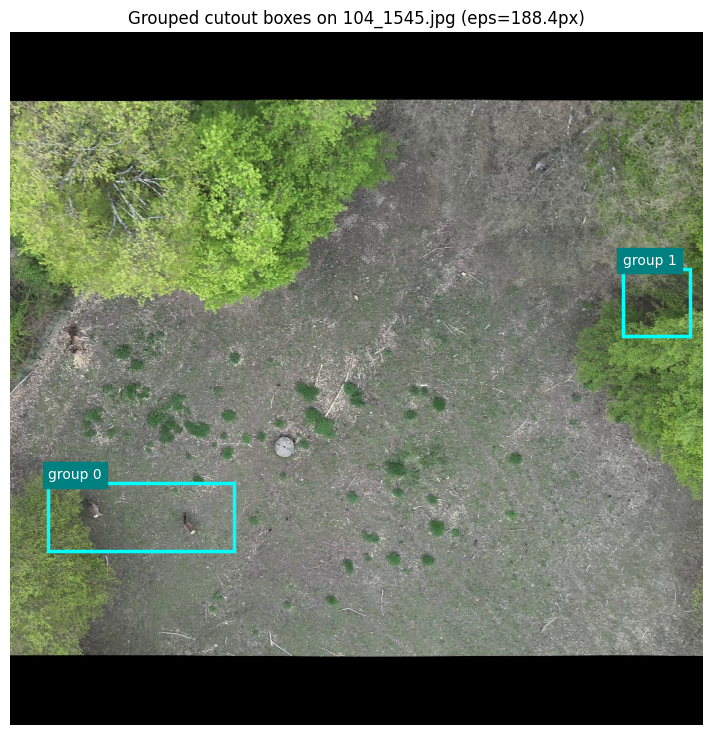

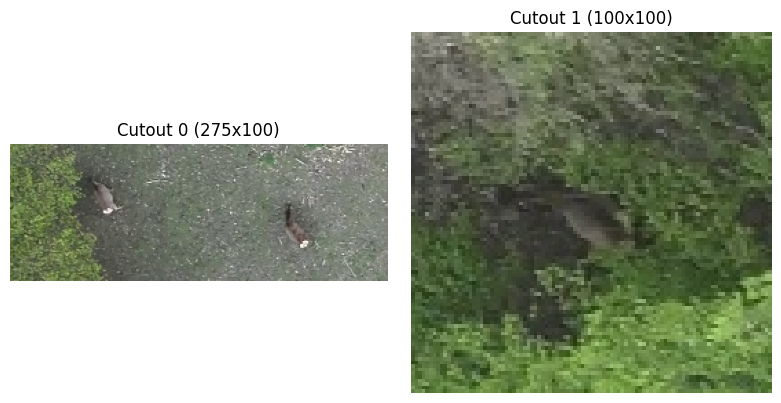

Detections: 3
Groups found: 2
Clustering eps (pixels): 188.36


In [35]:
from math import hypot


def _connected_components(points, eps):
    """Simple radius-graph clustering (DBSCAN-style with min_samples=1)."""
    n = len(points)
    visited = [False] * n
    clusters = []

    for i in range(n):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        component = []

        while stack:
            u = stack.pop()
            component.append(u)
            ux, uy = points[u]

            for v in range(n):
                if visited[v]:
                    continue
                vx, vy = points[v]
                if hypot(ux - vx, uy - vy) <= eps:
                    visited[v] = True
                    stack.append(v)

        clusters.append(component)

    return clusters


def cluster_group_cutouts(image_path, label_path, eps_scale=3.0, margin_ratio=0.2, min_cluster_size=1, min_bounding_bluster_size = 100):
    """
    Cluster animal detections into spatial groups and return cropped group images.

    Args:
        image_path: Path to image file.
        label_path: Path to YOLO label file (class x_center y_center width height).
        eps_scale: Radius scale for clustering based on median box diagonal.
        margin_ratio: Extra margin around each grouped crop.
        min_cluster_size: Minimum number of detections required for a cluster.

    Returns:
        dict with:
            - image: PIL image
            - detections: parsed detections with pixel boxes
            - clusters: list of cluster index lists
            - group_boxes: list of (x1, y1, x2, y2)
            - cutouts: list of PIL cropped images
            - eps_px: clustering radius in pixels
    """
    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    detections = []
    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            class_id, x_c, y_c, w, h = line.split()
            class_id = int(class_id)
            x_c = float(x_c)
            y_c = float(y_c)
            w = float(w)
            h = float(h)

            x_min, y_min, box_w, box_h = yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h)
            x_max = x_min + box_w
            y_max = y_min + box_h

            detections.append(
                {
                    "class_id": class_id,
                    "x_center": x_c * img_w,
                    "y_center": y_c * img_h,
                    "x_min": x_min,
                    "y_min": y_min,
                    "x_max": x_max,
                    "y_max": y_max,
                    "box_w": box_w,
                    "box_h": box_h,
                }
            )

    if not detections:
        return {
            "image": image,
            "detections": [],
            "clusters": [],
            "group_boxes": [],
            "cutouts": [],
            "eps_px": 0.0,
        }

    diagonals = [hypot(d["box_w"], d["box_h"]) for d in detections]
    diagonals_sorted = sorted(diagonals)
    median_diag = diagonals_sorted[len(diagonals_sorted) // 2]
    eps_px = max(1.0, eps_scale * median_diag)

    points = [(d["x_center"], d["y_center"]) for d in detections]
    clusters = _connected_components(points, eps_px)
    clusters = [c for c in clusters if len(c) >= min_cluster_size]

    group_boxes = []
    cutouts = []

    for cluster in clusters:
        x1 = min(detections[i]["x_min"] for i in cluster)
        y1 = min(detections[i]["y_min"] for i in cluster)
        x2 = max(detections[i]["x_max"] for i in cluster)
        y2 = max(detections[i]["y_max"] for i in cluster)

        bw = x2 - x1
        bh = y2 - y1
        mx = bw * margin_ratio
        if bw < min_bounding_bluster_size and bw +2 * mx < min_bounding_bluster_size:
            dif = min_bounding_bluster_size - bw
            mx = dif/2
        my = bh * margin_ratio
        if bh < min_bounding_bluster_size and bh +2 * my < min_bounding_bluster_size:
            dif = min_bounding_bluster_size - bh
            my = dif/2

        x1 = max(0, int(round(x1 - mx)))
        y1 = max(0, int(round(y1 - my)))
        x2 = min(img_w, int(round(x2 + mx)))
        y2 = min(img_h, int(round(y2 + my)))

        group_boxes.append((x1, y1, x2, y2))
        cutouts.append(image.crop((x1, y1, x2, y2)))

    return {
        "image": image,
        "detections": detections,
        "clusters": clusters,
        "group_boxes": group_boxes,
        "cutouts": cutouts,
        "eps_px": eps_px,
    }


# Demo on frame 55_4650
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

demo_image_path = project_root / "data" / "rgb_images" / "train" / "104_1545.jpg"
demo_label_path = project_root / "data" / "labels_matched_rgb" / "train" / "104_1545.txt"

result = cluster_group_cutouts(
    image_path=demo_image_path,
    label_path=demo_label_path,
    eps_scale=3.0,
    margin_ratio=0.25,
    min_cluster_size=1,
)

# Show original image with grouped cutout boxes.
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(result["image"])
for i, (x1, y1, x2, y2) in enumerate(result["group_boxes"]):
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.5, edgecolor="cyan", facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, max(2, y1 - 6), f"group {i}", color="white", fontsize=10, backgroundcolor="teal")
ax.set_title(f"Grouped cutout boxes on {demo_image_path.name} (eps={result['eps_px']:.1f}px)")
ax.axis("off")
plt.show()

# Show each extracted cutout.
cutouts = result["cutouts"]
if cutouts:
    cols = min(4, len(cutouts))
    rows = (len(cutouts) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()

    for i, crop in enumerate(cutouts):
        axes[i].imshow(crop)
        axes[i].set_title(f"Cutout {i} ({crop.size[0]}x{crop.size[1]})")
        axes[i].axis("off")

    for j in range(len(cutouts), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

print(f"Detections: {len(result['detections'])}")
print(f"Groups found: {len(result['clusters'])}")
print(f"Clustering eps (pixels): {result['eps_px']:.2f}")

## Find Frame with 2 groups

Found frame: 104_1545
Groups found: 2
Files checked: 65


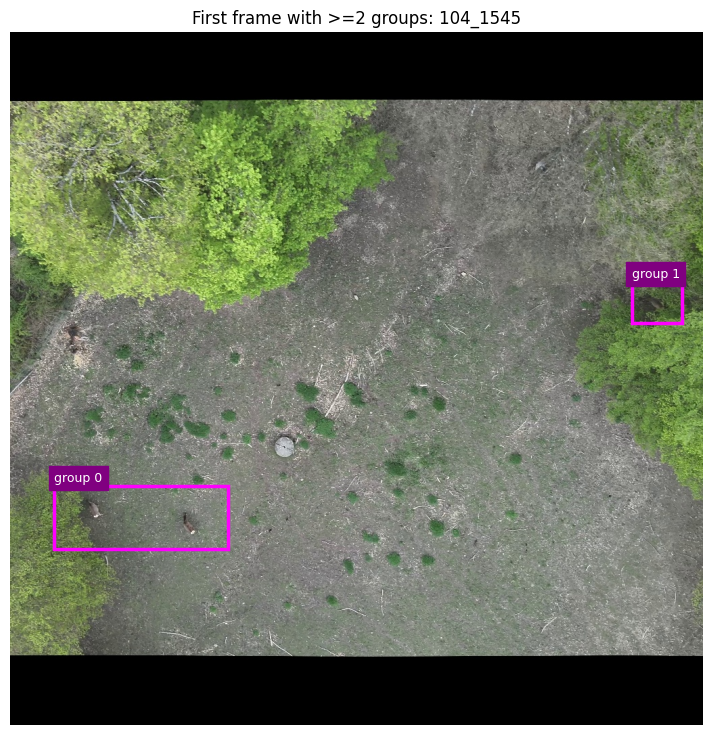

In [7]:
def find_frame_with_min_groups(
    labels_dir,
    images_dir,
    min_groups=2,
    eps_scale=3.0,
    margin_ratio=0.2,
    min_cluster_size=1,
    max_files=None,
):
    """
    Scan YOLO label files and return the first frame that contains at least `min_groups` clusters.

    Returns:
        dict with keys: frame_id, image_path, label_path, groups_found, result
        or None if no matching frame is found.
    """
    labels_dir = Path(labels_dir)
    images_dir = Path(images_dir)

    label_files = sorted(labels_dir.glob("*.txt"))
    checked = 0

    for label_file in label_files:
        frame_id = label_file.stem
        image_file = images_dir / f"{frame_id}.jpg"

        if not image_file.exists():
            continue

        res = cluster_group_cutouts(
            image_path=image_file,
            label_path=label_file,
            eps_scale=eps_scale,
            margin_ratio=margin_ratio,
            min_cluster_size=min_cluster_size,
        )

        checked += 1
        groups_found = len(res["clusters"])

        if groups_found >= min_groups:
            return {
                "frame_id": frame_id,
                "image_path": image_file,
                "label_path": label_file,
                "groups_found": groups_found,
                "result": res,
                "files_checked": checked,
            }

        if max_files is not None and checked >= max_files:
            break

    return None


# Demo search in test split.
search_labels_dir = project_root / "data" / "labels_matched_rgb" / "train"
search_images_dir = project_root / "data" / "rgb_images" / "train"

match = find_frame_with_min_groups(
    labels_dir=search_labels_dir,
    images_dir=search_images_dir,
    min_groups=2,
    eps_scale=3.0,
    margin_ratio=0.2,
    min_cluster_size=1,
)

if match is None:
    print("No frame with at least 2 groups found using current parameters.")
else:
    print(f"Found frame: {match['frame_id']}")
    print(f"Groups found: {match['groups_found']}")
    print(f"Files checked: {match['files_checked']}")

    # Optional quick visualization of found grouped boxes.
    found_result = match["result"]
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(found_result["image"])

    for i, (x1, y1, x2, y2) in enumerate(found_result["group_boxes"]):
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.5, edgecolor="magenta", facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(2, y1 - 6), f"group {i}", color="white", fontsize=9, backgroundcolor="purple")

    ax.set_title(f"First frame with >=2 groups: {match['frame_id']}")
    ax.axis("off")
    plt.show()